## Preamble

This notebook serves as a demo for the experanto package. 

Here we show our old approach for storing data in a hierarchical file structure and building model dataloaders through aligning and interpolating our various data modalities.

(This predates our move to object storage).

To get started, first download the zst tarball for an experiment session from [here](https://drive.google.com/file/d/1DU5RBYz7DITsk1XIIZkR22XTOKtZrJTV/view?usp=sharing) (~50 GB compressed, ~120 GB after extraction).

This data can be extracted using `tar`: `tar --zstd -xf /path/to/35_3832003544063_1_V1.tar.zst`

### Data modalities

(*Note*: we're not here including model embeddings nor video captions nor other forms of subject behavior data, but we will be working with these modalities in the near future. Additionally, in the further future we'll be working with even more modalities, e.g. audio data)

The data modalities we showcase in this experiment session are `screen`, `responses`, and `eye_tracker`.

`screen` pertains to the presented videos during an experiment. 

`responses` are the neural responses (time-binned spike counts) of the subject.

`eye_tracker` is the x,y coordinates of the subject's gaze on the screen.

The layout of the data is as follows:

```
35_3832003544063_1_V1/                    # Session root
│
├── meta.json                             # Session-level metadata
│
├── responses                             # Neural responses
│   ├── data.mem                          # Memory-mapped spike counts (T × n_neurons)
│   ├── meta.yml                          # Device metadata
│   └── meta/                             # Additional individual neuron metadata
│
│
├── eye_tracker/                          # Gaze position + pupil size
│   ├── data.mem                          # (T × 3) - x, y, pupil
│   ├── meta.yml                          # Device metadata
│   └── meta/                             # Additional individual eye tracker metadata
│
└── screen/                                # Visual stimuli
     ├── meta.yml                          # Trial timing info
     ├── combined_meta.json                # All trial metadata combined
     ├── timestamps.npy                    # Frame timestamps
     ├── data/                             # Trial video/image files
     │   ├── 00001.npy                     # Trial 1 frames (C×T×H×W or H×W×C)
     │   ├── 00002.npy                     # Trial 2 frames
     │   ├── ...                           # ~4616 trial files
     │   └── NNNNN.npy
     └── meta/                             # Per-trial metadata
         ├── 00001.yaml
         ├── 00002.yaml
         ├── ...
         └── NNNNN.yaml
```

For each modality, we have data, metadata, and timestamps.

Based on these modalities and the metadata, we can filter and construct aligned chunks of data across modalities at arbitrary sampling rates.

#### Continuous signals

For continuous signals (e.g. `responses`), the data (`...responses/data.mem`) is one large numpy array, and we save `start_time`, `end_time`, and `sampling_rate` in the metadata (`...responses/meta.yml`). From this metadata we can reconstruct the signals at arbitrary time and resolution.

Example `...responses/meta.yml`:

```
dtype: float64
end_time: 10952.275666655
is_mem_mapped: true
modality: sequence
n_signals: 1225
n_timestamps: 328568
phase_shift_per_signal: false
sampling_rate: 30
start_time: 0.01666665499987826
```







#### Discrete signals

For discrete signals (e.g. `screen`), the data (`...screen/data/*.npy`) is a list of numpy arrays, one for each video. For each video we also save its corresponding metadata in `...screen/meta/*.yaml`. 

Example `...screen/meta/00001.yaml`:

```
first_frame_idx: 1
image_size:
- 50
- 236
- 420
- 3
modality: video
movie_id: 'null'
num_frames: 50
tier: validation
trial_idx: 0
valid_trial: true
```

Here, `first_frame_idx` corresponds to the index in `...screen/timestamps.npy` of the first frame of the video.

`timestamps.npy` is a large, 1-D array that stores *all* timestamps of *all* video data as well as gray screen frames
during pauses in the experiment.

## Setup

Run imports.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import treescope as ts
from tqdm import tqdm

from experanto.configs import BENCHMARKING_CONFIG as cfg
from experanto.dataloaders import get_multisession_concat_dataloader
from experanto.utils import handle_responses_field

%matplotlib inline
%load_ext autoreload
%autoreload 2

## >> Set path to raw data



In [2]:
# SET THIS TO THE ROOT DIRECTORY OF THE EXTRACTED DATA.
data_paths = [
    (Path.home() / "data" / "35_3832003544063_1_V1"),
]

assert all(p.exists() for p in data_paths)

## Set config

Our first step in building a dataloader is setting the config for our various data modalities. 

The two most important parameters for each modality are the `sampling_rate` and `chunk_size`. 

The `sampling_rate` is specified in Hz, and dictates how the data is binned and interpolated
within the dataloader.

The `chunk_size` is the number of samples in a training example. 

So, the temporal duration of a particular modality within a training example is $\frac{\text{chunk size}}{\text{sampling rate}}$

For example, if we have a sampling rate of 30 Hz and a chunk size of 60 samples, then each training example contains 2 seconds of data.

Experanto supports different sampling rates and chunk sizes per modality, but here we use one sampling rate and one chunk size across modalities to ensure temporal alignment.

In [3]:
sampling_rate = 30  # Hz
chunk_size = 100  # samples
batch_size = 8

cfg = handle_responses_field(cfg)

cfg.dataloader.batch_size = batch_size

# Set common parameters across all modalities
modalities = ["screen", "eye_tracker", "responses"]
for modality in modalities:
    cfg.dataset.modality_config[modality].sampling_rate = sampling_rate
    cfg.dataset.modality_config[modality].chunk_size = chunk_size

cfg.dataloader.prefetch_factor = None
cfg.dataloader.num_workers = 0

We can also inspect the full config if we like.

In [4]:
ts.show(cfg)

DictConfig({
  'dataset': DictConfig({
    'global_sampling_rate': None,
    'global_chunk_size': None,
    'add_behavior_as_channels': False,
    'replace_nans_with_means': False,
    'modality_config': DictConfig({'screen': DictConfig({'keep_nans': False, 'sampling_rate': 30, 'chunk_size': 100, 'valid_condition': DictConfig({'tier': 'train'}), 'offset': 0, 'sample_stride': 1, 'include_blanks': True, 'transforms': DictConfig({'normalization': False}), 'interpolation': DictConfig({'rescale': False, 'rescale_size': None, 'dtype': 'float16', 'interleave_value': ListConfig([0.40354313, 0.55193976, 0.70105263])})}), 'responses_30Hz_permissive_stability_criteria': DictConfig({'keep_nans': False, 'sampling_rate': 30, 'chunk_size': 16, 'offset': 0, 'transforms': DictConfig({'normalization': 'standardize'}), 'interpolation': DictConfig({'interpolation_mode': 'nearest_neighbor'})}), 'eye_tracker': DictConfig({'keep_nans': False, 'sampling_rate': 30, 'chunk_size': 100, 'offset': 0, 'transforms': DictConfig({'normalization': False}), 'interpolation': DictConfig({'interpolation_mode': 'nearest_neighbor'})}), 'blinks': DictConfig({'keep_nans': False, 'sampling_rate': 30, 'chunk_size': 16, 'offset': 0, 'transforms': DictConfig({'normalization': False}), 'interpolation': DictConfig({'interpolation_mode': 'nearest_neighbor'})}), 'responses': DictConfig({'keep_nans': False, 'sampling_rate': 30, 'chunk_size': 100, 'offset': 0, 'transforms': DictConfig({'normalization': 'standardize'}), 'interpolation': DictConfig({'interpolation_mode': 'nearest_neighbor'})})}),
  }),
  'dataloader': DictConfig({
    'batch_size': 8,
    'shuffle': True,
    'num_workers': 0,
    'pin_memory': False,
    'drop_last': True,
    'prefetch_factor': None,
  }),
  'datapath': DictConfig({'files': ListConfig(['35_3832003544063_1_V1']), 'root': '/path/to/dataset'}),
  'distributed': DictConfig({'backend': 'nccl', 'datasets_per_rank': 1, 'sync_epochs': True, 'min_samples_per_epoch': 10000, 'max_batches': 1000, 'move_to_device': True}),
})

### Config reference

More detailed configuration options can be seen below:

#### Dataset-Level Options

| Parameter | Type | Description |
|-----------|------|-------------|
| `global_sampling_rate` | int/null | Override all modality sampling rates |
| `global_chunk_size` | int/null | Override all modality chunk sizes |
| `add_behavior_as_channels` | bool | Merge eye_tracker/treadmill as screen channels |
| `replace_nans_with_means` | bool | Replace NaN values with batch column means |

#### Per-Modality Options

| Parameter | Type | Description |
|-----------|------|-------------|
| `sampling_rate` | int | Hz - samples per second |
| `chunk_size` | int | Samples per training example |
| `offset` | float | Time shift in seconds (e.g., 0.1 for 100ms lag) |
| `sample_stride` | int | Skip every N chunks (1 = use all) |
| `keep_nans` | bool | Preserve NaN values after interpolation |
| `include_blanks` | bool | Include blank/no-stimulus trials (screen only) |
| `valid_condition` | dict | Metadata filters (e.g., `{tier: train}`) |

#### Interpolation Options

| Parameter | Type | Description |
|-----------|------|-------------|
| `interpolation_mode` | str | `"nearest_neighbor"` or `"linear"` |
| `rescale` | bool | Resize images (screen only) |
| `rescale_size` | list | Target resolution `[H, W]` |
| `dtype` | str | Output dtype (`"float16"`, `"float32"`, `"uint8"`) |

#### Transform Options

| Parameter | Values | Description |
|-----------|--------|-------------|
| `normalization` | `"normalize"` | Z-score using saved statistics |
| | `"standardize"` | Subtract mean, divide by std |
| | `False` | No normalization |
| | dict | Custom `{mean: [...], std: [...]}` |

## Explore dataloader

Now, from our data path and config, we can build a dataloader. One nice feature of experanto is that it can build a single dataloader that handles multiple sessions of data. Here we use a single session for demonstration.

In [5]:
train_dl = get_multisession_concat_dataloader(data_paths, cfg)  # type: ignore

Dataset 0: 35_3832003544063_1_V1, length = 164349
Sessions: ['35_3832003544063_1_V1']
Batches per session: {'35_3832003544063_1_V1': 20543}
Total batches: 20543
Created FastSessionDataLoader with 1 sessions and 20543 total batches


/home/jkbhagat/enigma-brain/experanto/.venv/lib/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


### Explore a batch within a dataloader

In [6]:
_data_key, batch = next(iter(train_dl))

In [7]:
print(batch.keys())  # batch keys are the timestamps and modalities

dict_keys(['responses', 'eye_tracker', 'screen', 'timestamps'])


And now we can quickly inspect the timestamps and modalities.

In [8]:
ts.show(batch["timestamps"])

{
  'responses': <torch.Tensor float32(8, 100) ≈3.7e+03 ±6.2e+06 [≥3.6e+02, ≤8.4e+03] nonzero:800>,
  'eye_tracker': <torch.Tensor float32(8, 100) ≈3.7e+03 ±6.2e+06 [≥3.6e+02, ≤8.4e+03] nonzero:800>,
  'screen': <torch.Tensor float32(8, 100) ≈3.7e+03 ±6.2e+06 [≥3.6e+02, ≤8.4e+03] nonzero:800>,
}

In [9]:
ts.show(batch["screen"])

<torch.Tensor float32(8, 3, 100, 236, 420)>

In [10]:
ts.show(batch["responses"])

<torch.Tensor float32(8, 100, 833)>

In [11]:
ts.show(batch["eye_tracker"])

<torch.Tensor float32(8, 100, 3) ≈-3.2e+04 ±2.1e+09 [≥-1.1e+05, ≤1.2e+02] nonzero:2_400>

### Visualize data

Following the quick inspection of the batch, we can create slightly nicer data viz.

We can visualize the presented screen frames from a single batch.

Screen tensor shape: torch.Size([8, 3, 100, 236, 420])


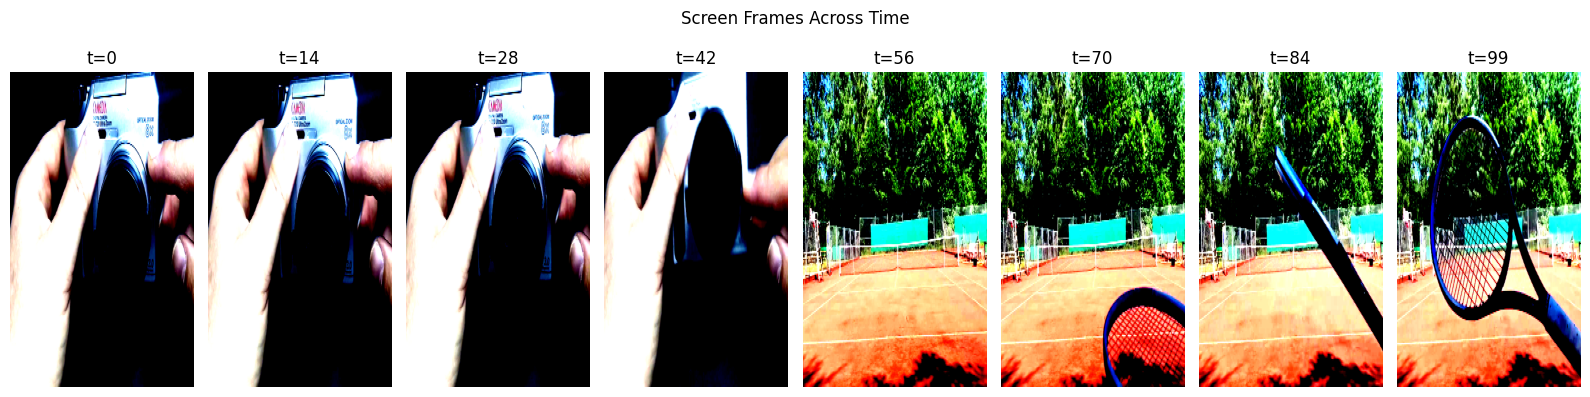

In [14]:
screen = batch["screen"]  # (B, C, T, H, W)
print(f"Screen tensor shape: {screen.shape}")

# Show frames from first sample in batch
sample_idx = 0
n_frames = min(8, screen.shape[2])
frame_indices = np.linspace(0, screen.shape[2] - 1, n_frames, dtype=int)

fig, axes = plt.subplots(1, n_frames, figsize=(16, 4))
for i, frame_idx in enumerate(frame_indices):
    frame = screen[sample_idx, :, frame_idx].permute(1, 2, 0).numpy()
    frame = frame.astype(np.float32)
    axes[i].imshow(frame.clip(0, 1), aspect='auto')
    axes[i].set_title(f"t={frame_idx}")
    axes[i].axis("off")

plt.suptitle("Screen Frames Across Time")
plt.tight_layout()


And we can visualize neural responses to these screen frames.


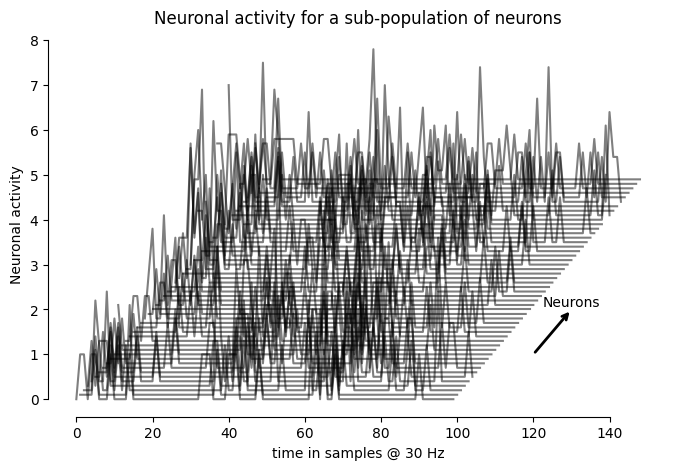

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

n_samples = 100
n_neurons = 50
for n in range(n_neurons):
    t = np.arange(n, n_samples + n)  # x-axis offset for each neuron
    responses = batch["responses"][i, :, n] + 0.1 * n
    axs.plot(t, responses, color="black", alpha=0.5)

# Define points
point_a = (120, 1)
point_b = (130, 2)
axs.annotate(
    "", xy=point_b, xytext=point_a, arrowprops={"arrowstyle": "->", "lw": 2, "color": "k"}
)

# Add text above the arrow
mid_x = (point_a[0] + point_b[0]) / 2
mid_y = (point_a[1] + point_b[1]) / 2
axs.text(mid_x + 5, mid_y + 0.5, "Neurons", ha="center", va="bottom")

axs.set(
    xlabel="time in samples @ 30 Hz",
    ylabel="Neuronal activity",
    title="Neuronal activity for a sub-population of neurons",
)
sns.despine(
    trim=True,
)

And we can visualize eye tracking during this time.

Eye tracker tensor shape: torch.Size([8, 100, 3])


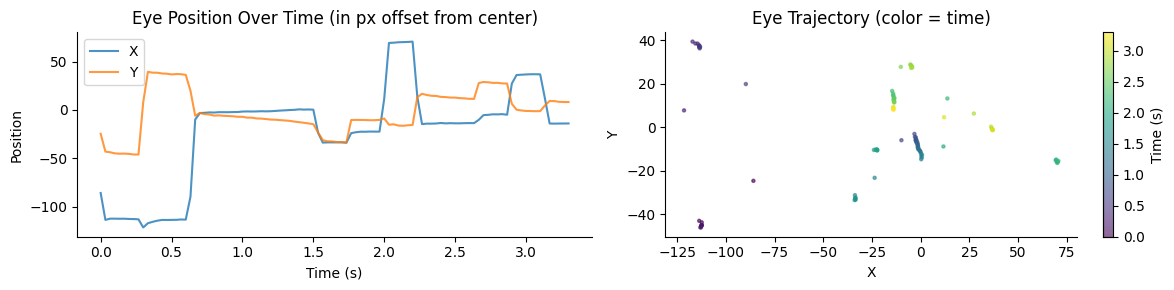

In [ ]:
eye_tracker = batch["eye_tracker"]  # (B, T, 2-3)
print(f"Eye tracker tensor shape: {eye_tracker.shape}")

sample_idx = 0
eye_data = eye_tracker[sample_idx].numpy()
time = np.arange(len(eye_data)) / sampling_rate

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Time series
axes[0].plot(time, eye_data[:, 0], label='X', alpha=0.8)
axes[0].plot(time, eye_data[:, 1], label='Y', alpha=0.8)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Position")
axes[0].set_title("Eye Position Over Time (in px offset from center)")
axes[0].legend()

# 2D trajectory
colors = plt.cm.viridis(np.linspace(0, 1, len(eye_data)))  # type: ignore
scatter = axes[1].scatter(eye_data[:, 0], eye_data[:, 1], c=time, cmap='viridis', s=5, alpha=0.6)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Eye Trajectory")
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Time (s)")

plt.tight_layout()
sns.despine()

### Cross-Modal Alignment

A key feature of experanto is aligning data across modalities with different native rates.

E.g. we can get neural responses at exact screen timestamps

In [17]:
# Get timestamps of the screen for the first item of the batch
dataset = train_dl.dataset.datasets[0]
screen_timestamps = batch["timestamps"]["screen"][0, :].numpy()

ts.show(screen_timestamps) # 100 timestamps in seconds

<np.ndarray float32(100,) ≈8.6e+02 ±0.96 [≥8.6e+02, ≤8.7e+02] nonzero:100>

In [18]:
# Get neural responses interpolated at screen timestamps
responses_interp, _ = dataset._experiment.devices["responses"].interpolate(screen_timestamps)

ts.show(responses_interp) # (100 timestamps, 833 neurons)

# np.ndarray float32(100, 833) ≈0.099 ±0.42 [≥0.0, ≤1.1e+01] zero:77_296 nonzero:6_004
  array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 2., 0., 0.],
         [0., 0., 0., ..., 2., 0., 0.],
         [0., 1., 0., ..., 3., 0., 0.]], dtype=float32)

### Additional Dataloader details

An experiment dataloader contains the following important components:
- `dataset`: All the data within the dataloader

- `dataset.datasets`: A list of "chunk datasets" each with size `chunk_size` that belong to the overall `dataset`
    
    - The data within a batch in `dataset.datasets` can be indexed as: `dataloader.dataset.datasets[<chunk_index>][<batch_index>][<modality>]`

- `dataset.datasets[<index>]._experiment`: An experiment object is the low-level interface for accessing multi-modal data with interpolation.

- `dataset.datasets[<index>]._experiment.devices`: A dict of `modality : interpolator` for each modality in the experiment session.  

#### `Experiment` object

In [17]:
exp = train_dl.dataset.datasets[0]._experiment

print(f"Available devices: {exp.device_names}")
print(f"Session time range: {exp.start_time:.2f}s to {exp.end_time:.2f}s")
print(f"Total duration: {(exp.end_time - exp.start_time) / 60:.1f} minutes")

Available devices: ('eye_tracker', 'responses', 'screen')
Session time range: 117.06s to 10796.32s
Total duration: 178.0 minutes


---

# Benchmarking throughput

Lastly, we show how to benchmark the throughput of the dataloader.

Ideally, we'd love to use Spiral to include and build on the functionality of our dataloader 
we've shown above, while also significantly improving dataloader throughput.

#### settings we currently use for model training

In [18]:
sampling_rate = 30  # Hz
chunk_size = 16  # samples => corresponds to ~0.5s worth of data
batch_size = 8

cfg = handle_responses_field(cfg)

cfg.dataloader.batch_size = batch_size

# Set common parameters across all modalities
modalities = ['screen', 'eye_tracker', 'responses']
for modality in modalities:
    cfg.dataset.modality_config[modality].sampling_rate = sampling_rate
    cfg.dataset.modality_config[modality].chunk_size = chunk_size

cfg.dataloader.batch_size=8
cfg.dataloader.num_workers=16
cfg.dataloader.pin_memory=False
cfg.dataloader.prefetch_factor=2

#### build dataloader again with updated config

In [19]:
train_dl = get_multisession_concat_dataloader(data_paths, cfg)  # type: ignore

Dataset 0: 35_3832003544063_1_V1, length = 201645
Sessions: ['35_3832003544063_1_V1']
Batches per session: {'35_3832003544063_1_V1': 25205}
Total batches: 25205
Created FastSessionDataLoader with 1 sessions and 25205 total batches


#### run simple throughput experiment

In [20]:
for i, batch in tqdm(enumerate(train_dl)):
    if i > 1000:
        break

1001it [00:33, 30.19it/s]


#### Throughput

In [21]:
it_per_s = 30.19
bs = cfg.dataloader.batch_size
frames_per_chunk = cfg.dataset.modality_config.screen.chunk_size

print(f"Throughput = {it_per_s * bs * frames_per_chunk} movie frames/sec",)

Throughput = 3864.32 movie frames/sec
